In [1]:
import ee
import geemap

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
ee.Authenticate()
ee.Initialize()

print("Earth Engine connected!")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine connected!


In [4]:
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [5]:
Map.set_center(74.35, 31.55, 9)
Map

Map(bottom=1276.0, center=[31.55, 74.35], controls=(WidgetControl(options=['position', 'transparent_bg'], posi…

In [6]:
aoi = ee.Geometry.Rectangle([
    74.0, 31.2,
    74.7, 31.8
])

Map = geemap.Map()
Map.centerObject(aoi, 9)
Map.addLayer(aoi, {}, "Study Area")
Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2025-01-01", "2025-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

print("Images:", s2.size().getInfo())

Images: 362


In [8]:
image = s2.median().clip(aoi)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    image,
    {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000},
    "Sentinel-2"
)

Map

Map(center=[31.5001553654323, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [9]:
ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    ndvi,
    {"min": -1, "max": 1},
    "NDVI"
)

Map

Map(center=[31.5001553654323, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [10]:
ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    ndwi,
    {"min": -1, "max": 1},
    "NDWI"
)

Map

Map(center=[31.5001553654323, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [11]:
ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    ndwi,
    {"min": -1, "max": 1},
    "NDWI"
)

Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [12]:
stats = ndvi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
)

print("Mean NDVI:", stats.get("NDVI").getInfo())

Mean NDVI: 0.3752384730050815


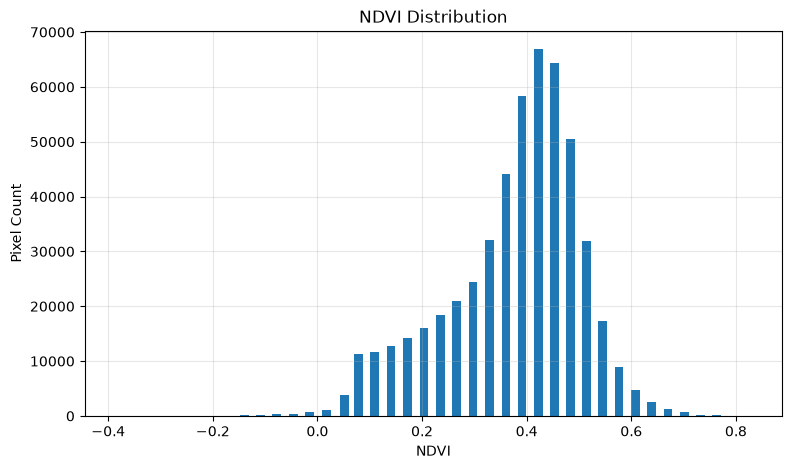

In [17]:
import matplotlib.pyplot as plt

hist = ndvi.reduceRegion(
    reducer=ee.Reducer.histogram(maxBuckets=50),
    geometry=aoi,
    scale=100,
    maxPixels=1e6
).get("NDVI").getInfo()

counts = hist["histogram"]
bins = hist["bucketMeans"]

plt.figure(figsize=(9, 5))
plt.bar(bins, counts, width=(bins[1] - bins[0]))
plt.xlabel("NDVI")
plt.ylabel("Pixel Count")
plt.title("NDVI Distribution")
plt.grid(alpha=0.3)
plt.show()

In [18]:
def monthly_ndvi(month):
    start = ee.Date.fromYMD(2025, month, 1)
    end = start.advance(1, "month")

    img = (
        s2.filterDate(start, end)
        .median()
        .normalizedDifference(["B8", "B4"])
        .rename("NDVI")
    )

    return ee.Feature(
        None,
        {"month": month, "NDVI": img.reduceRegion(
            ee.Reducer.mean(), aoi, 100, maxPixels=1e9
        ).get("NDVI")}
    )

In [20]:
import pandas as pd

monthly = ee.FeatureCollection([
    monthly_ndvi(m) for m in range(1, 13)
])

features = monthly.getInfo()["features"]
data = pd.DataFrame([feature["properties"] for feature in features])
data = data.sort_values("month").reset_index(drop=True)

data

,NDVI,month
0,0.527787,1
1,0.569589,2
2,0.585784,3
3,0.293938,4
4,0.199610,5
5,0.198909,6
6,0.305502,7
7,0.467436,8
8,0.512355,9
9,0.383908,10


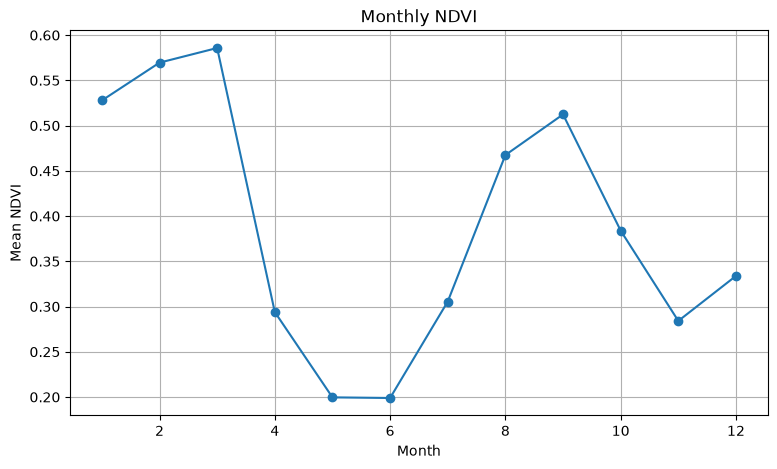

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(data["month"], data["NDVI"], marker="o")

plt.xlabel("Month")
plt.ylabel("Mean NDVI")
plt.title("Monthly NDVI")

plt.grid(True)
plt.show()

In [22]:
landsat = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2025-06-01", "2025-08-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))
    .median()
    .clip(aoi)
)

In [23]:
lst = (
    landsat.select("ST_B10")
    .multiply(0.00341802)
    .add(149.0)
    .subtract(273.15)
    .rename("LST")
)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    lst,
    {"min": 20, "max": 50},
    "Land Surface Temperature"
)

Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [24]:
dem = ee.Image("USGS/SRTMGL1_003").clip(aoi)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    dem,
    {"min": 0, "max": 1500},
    "Elevation"
)

Map

Map(center=[31.5001553654323, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [25]:
dem = ee.Image("USGS/SRTMGL1_003").clip(aoi)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    dem,
    {"min": 0, "max": 1500},
    "Elevation"
)

Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [27]:
ndvi_2018 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2018-01-01", "2018-12-31")
    .median()
    .normalizedDifference(["B8", "B4"])
)

ndvi_2025 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2025-01-01", "2025-12-31")
    .median()
    .normalizedDifference(["B8", "B4"])
)

In [28]:
change = ndvi_2025.subtract(ndvi_2018)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    change,
    {"min": -0.5, "max": 0.5},
    "NDVI Change"
)

Map

Map(center=[31.5001553654323, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_bg…

In [29]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate("2025-01-01", "2025-03-31")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .select("VV")
    .median()
    .clip(aoi)
)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(s1, {}, "Sentinel-1 VV")
Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [30]:
rain = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate("2025-01-01", "2025-12-31")
    .sum()
    .clip(aoi)
)

Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(rain, {}, "Annual Rainfall")
Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

In [32]:
Map = geemap.Map()
Map.centerObject(aoi, 9)

Map.addLayer(
    ndvi,
    {"min": -1, "max": 1},
    "NDVI"
)

Map.addLayer(
    aoi,
    {},
    "Study Area"
)

Map

Map(center=[31.500155365432835, 74.35000000000034], controls=(WidgetControl(options=['position', 'transparent_…

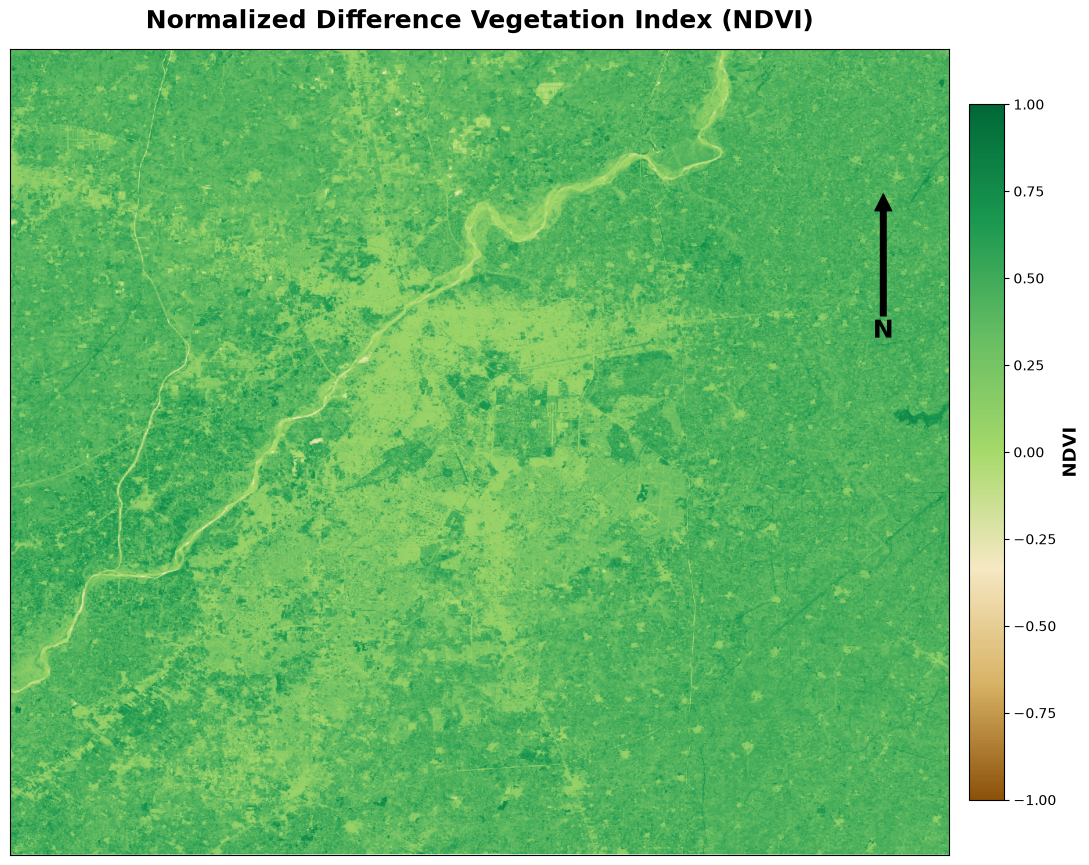

In [36]:
import ee
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

# -----------------------------
# 1. NDVI visualization
# -----------------------------
vis = {
    "min": -1,
    "max": 1,
    "palette": [
        "8c510a",
        "d8b365",
        "f6e8c3",
        "a6d96a",
        "66bd63",
        "1a9850",
        "006837"
    ]
}

# -----------------------------
# 2. Get image directly from GEE
# -----------------------------
url = ndvi.getThumbURL({
    "region": aoi,
    "dimensions": 1200,
    "format": "png",
    **vis
})

response = requests.get(url)
img = Image.open(BytesIO(response.content))

# -----------------------------
# 3. Create publication-style map
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 9))

ax.imshow(img)

# Title
ax.set_title(
    "Normalized Difference Vegetation Index (NDVI)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# -----------------------------
# 4. Grid
# -----------------------------
ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

# -----------------------------
# 5. Remove image ticks
# -----------------------------
ax.set_xticks([])
ax.set_yticks([])

# -----------------------------
# 6. North Arrow
# -----------------------------
ax.annotate(
    "N",
    xy=(0.93, 0.82),
    xytext=(0.93, 0.65),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=4,
        headwidth=12
    )
)

# -----------------------------
# 7. NDVI Legend / Colorbar
# -----------------------------
import matplotlib as mpl

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "ndvi",
    [
        "#8c510a",
        "#d8b365",
        "#f6e8c3",
        "#a6d96a",
        "#66bd63",
        "#1a9850",
        "#006837"
    ]
)

norm = mpl.colors.Normalize(vmin=-1, vmax=1)

sm = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "NDVI",
    fontsize=13,
    fontweight="bold"
)

# -----------------------------
# 8. Final layout
# -----------------------------
plt.tight_layout()
plt.show()

Upload and Plot Shapefile

In [1]:
import geopandas as gpd
import geemap
import ee

In [2]:
shp = r"C:\Users\PMLS\Downloads\New folder\shapefile\Export_Output_2.shp"
gdf = gpd.read_file(shp)
print('shapefile loaded successfully')

shapefile loaded successfully


In [3]:
print ("CRS:", gdf.crs)
print("features:", len(gdf))


CRS: EPSG:4326
features: 1


<Axes: >

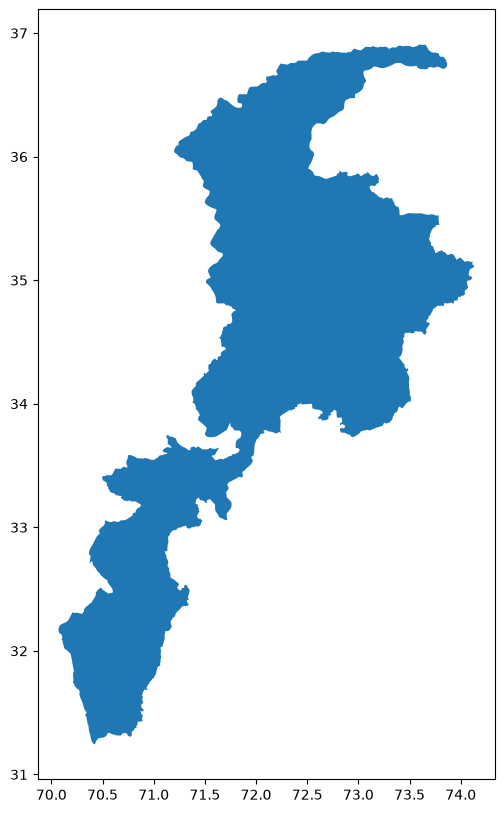

In [5]:
gdf.plot(figsize=(10, 10))

Convert This Shapefile to Earth Engine!

In [8]:
# Initialize Earth Engine before converting the GeoDataFrame
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

# Earth Engine expects geographic coordinates
if gdf.crs is not None and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs("EPSG:4326")

roi = geemap.geopandas_to_ee(gdf)

print("Converted GeoDataFrame to Earth Engine FeatureCollection successfully")
print ("Converted GeoDataFrame to Earth Engine FeatureCollection successfully")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Converted GeoDataFrame to Earth Engine FeatureCollection successfully
Converted GeoDataFrame to Earth Engine FeatureCollection successfully


Plot the shapefile on the interactive map 

In [9]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(roi, {}, "ROI")
Map

Map(center=[34.46154955337346, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Add DEM

In [10]:
dem = ee.Image("USGS/SRTMGL1_003").clip(roi)
print("DEM loaded and clipped to ROI successfully")

DEM loaded and clipped to ROI successfully


In [11]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(
    dem,
    {'min': 0, 'max': 3000, 'palette': ['006600', '00cc00', '66ff66', 'ffff00', 'ff9900', 'ff3300', 'cc0000']},
    "DEM"
)
Map.addLayer(roi, {"color": "black"}, "ROI")
Map

Map(center=[34.46154955337342, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Slope

In [12]:
slope = ee.Terrain.slope(dem)
print("slope calculated successfully")

slope calculated successfully


In [13]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(slope, {
    "min": 0, "max": 60, "palette": ["00ff00", "ffff00", "ff0000"]  
}, "Slope")
Map.addLayer(roi, {"color": "black"}, "ROI")
Map

Map(center=[34.46154955337346, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Aspect

In [14]:
aspect = ee.Terrain.aspect(dem)
print("Aspect calculated successfully")

Aspect calculated successfully


In [15]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(aspect, {
    "min": 0,
    "max": 360,
    "palette": ["0000ff", "00ffff", "00ff00", "ffff00", "ff0000", "ff00ff"]
}, "Aspect")
Map.addLayer(roi, {"color": "black"}, "ROI")
Map

Map(center=[34.46154955337346, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Hillshade

In [16]:
hillshade = ee.Terrain.hillshade(dem)
print("hillshade calculated successfully")

hillshade calculated successfully


In [17]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(hillshade, {"min": 0, "max": 255, "palette": ["000000", "ffffff"]}, "Hillshade")
Map.addLayer(roi, {"color": "black"}, "ROI")
Map

Map(center=[34.46154955337342, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Create Contours

In [18]:
contours = dem.divide(100).floor().multiply(100)
contours =contours.subtract(

    contours.focalMin(1)
).selfMask()
print("Contours calculated successfully")

Contours calculated successfully


In [19]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(contours, {"min": 0, "max": 1000, "palette": ["ffffff", "000000"]}, "Contours")
Map.addLayer(roi, {"color": "black"}, "Study Area")
Map

Map(center=[34.46154955337346, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Flow Accumulation

In [20]:
flow_acc = ee.Image(
    "MERIT/Hydro/v1_0_1"
).select("upa").clip(roi)
print("Flow accumulation loaded and clipped to ROI successfully")

Flow accumulation loaded and clipped to ROI successfully


In [21]:
flow_vis = flow_acc.log10()
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(flow_vis, {"min": 0, "max": 3, "palette": ["ffffff", "0000ff"]}, "Flow Accumulation ")
Map

Map(center=[34.46154955337342, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Drainage Network

In [22]:
drainage = flow_acc.gt(1000).selfMask()
print("Drainage network extracted successfully")

Drainage network extracted successfully


Display

In [24]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(drainage, {"color": "black"}, "Drainage Network")
Map.addLayer(roi, {"color": "black"}, "ROI")
Map

Map(center=[34.46154955337342, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Make One Terraon Map

In [25]:
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(roi, {}, "ROI")
Map.addLayer(dem, {"min": 0, "max": 3000, "palette": ["006600", "00cc00", "66ff66", "ffff00", "ff9900", "ff3300", "cc0000"]}, "DEM")
Map.addLayer(slope, {"min": 0, "max": 60, "palette": ["00ff00", "ffff00", "ff0000"]}, "Slope")
Map.addLayer(aspect, {"min": 0, "max": 360, "   palette": ["0000ff", "00ffff", "00ff00", "ffff00", "ff0000", "ff00ff"]}, "Aspect")
Map.addLayer(hillshade, {"min": 0, "max": 255, "palette": ["000000", "ffffff"]}, "Hillshade")
Map

Map(center=[34.46154955337346, 72.06950247008325], controls=(WidgetControl(options=['position', 'transparent_b…

Create Maps

In [26]:
import ee
import requests

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


In [29]:
from PIL import Image

In [30]:
from io import BytesIO  

Get the geographic extent of your shapefile

In [31]:
bounds = gdf.total_bounds  
xmin, ymin, xmax, ymax = bounds
print(f"Bounding box: xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}")

Bounding box: xmin=70.07002500000004, ymin=31.243101000000024, xmax=74.13194850000008, ymax=36.90857461300004


In [32]:
print("extent:")
print("xmin:", xmin)
print("ymin:", ymin)
print("xmax:", xmax)
print("ymax:", ymax)

extent:
xmin: 70.07002500000004
ymin: 31.243101000000024
xmax: 74.13194850000008
ymax: 36.90857461300004


Create Map function

In [38]:
def publication_map(
        image,
        vis,
        title,
        colorbar_label,
        cmap_name="terrain",
        vmin=None,
        vmax=None
):
    url = image.getThumbURL({
        "region": roi.geometry().bounds(),
        "dimensions": 1200,
        "format": "png",
        **vis
    })

    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    fig, ax = plt.subplots(figsize=(11, 9))

    ax.imshow(
        img,
        extent=(xmin, xmax, ymin, ymax),
        aspect="equal"
    )

    # title
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    # coordinate grid
    ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
    ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.5
    )

    # North Arrow
    ax.annotate(
        "N",
        xy=(0.93, 0.82),
        xytext=(0.93, 0.65),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=4,
            headwidth=12
        )
    )

    # Set Colorbar
    if vmin is not None and vmax is not None:
        cmap = plt.get_cmap(cmap_name)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.025)
        cbar.set_label(colorbar_label, fontsize=13, fontweight="bold")

    plt.tight_layout()
    return fig, ax

DEM map

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import requests
from PIL import Image
from io import BytesIO


def publication_map(
    image,
    vis,
    title,
    colorbar_label,
    vmin,
    vmax
):

    # -----------------------------
    # Get image from GEE
    # -----------------------------
    url = image.getThumbURL({
        "region": roi.geometry().bounds(),
        "dimensions": 1400,
        "format": "png",
        **vis
    })

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    # -----------------------------
    # Create figure
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(
        img,
        extent=[xmin, xmax, ymin, ymax]
    )

    # -----------------------------
    # Title
    # -----------------------------
    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=15
    )

    # -----------------------------
    # Coordinates
    # -----------------------------
    ax.set_xlabel(
        "Longitude (°)",
        fontsize=12
    )

    ax.set_ylabel(
        "Latitude (°)",
        fontsize=12
    )

    # -----------------------------
    # Grid
    # -----------------------------
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    # -----------------------------
    # North Arrow
    # -----------------------------
    ax.annotate(
        "N",
        xy=(0.94, 0.94),
        xytext=(0.94, 0.84),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=1.5,
            headwidth=7
        )
    )

    # -----------------------------
    # SAME GEE PALETTE
    # -----------------------------
    palette = vis["palette"]

    # Convert HEX colors to Matplotlib colormap
    colors = ["#" + c for c in palette]

    cmap = LinearSegmentedColormap.from_list(
        "gee_palette",
        colors
    )

    norm = mpl.colors.Normalize(
        vmin=vmin,
        vmax=vmax
    )

    sm = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cmap
    )

    sm.set_array([])

    # -----------------------------
    # Colorbar
    # -----------------------------
    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.035,
        pad=0.025
    )

    cbar.set_label(
        colorbar_label,
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

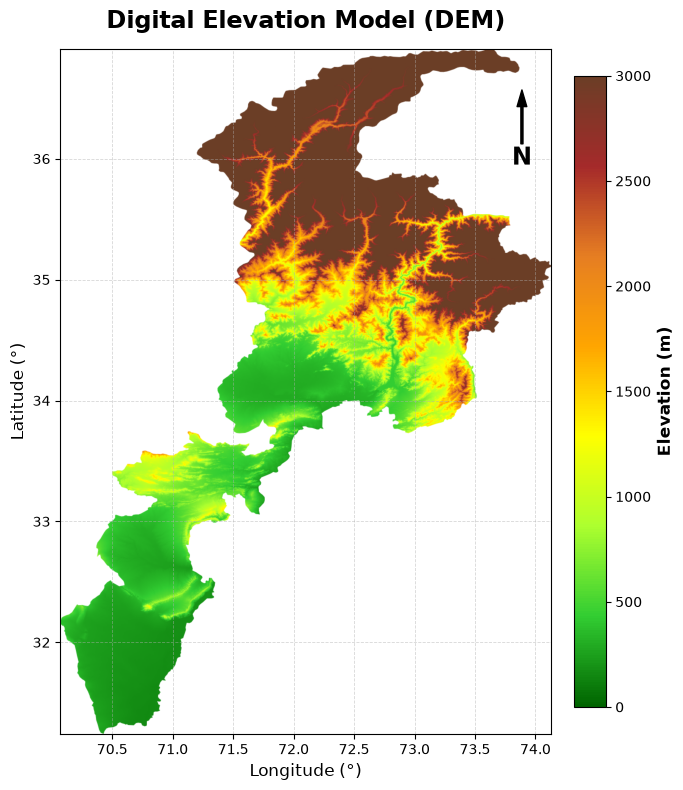

In [52]:
dem_vis = {
    "min": 0,
    "max": 3000,
    "palette": [
        "006400",   # Dark green
        "32CD32",   # Green
        "ADFF2F",   # Yellow-green
        "FFFF00",   # Yellow
        "FFA500",   # Orange
        "E67E22",   # Dark orange
        "A52A2A",   # Brown
        "6B3E26"    # Dark brown
    ]
}

publication_map(
    dem,
    dem_vis,
    "Digital Elevation Model (DEM)",
    "Elevation (m)",
    0,
    3000
)

slope map

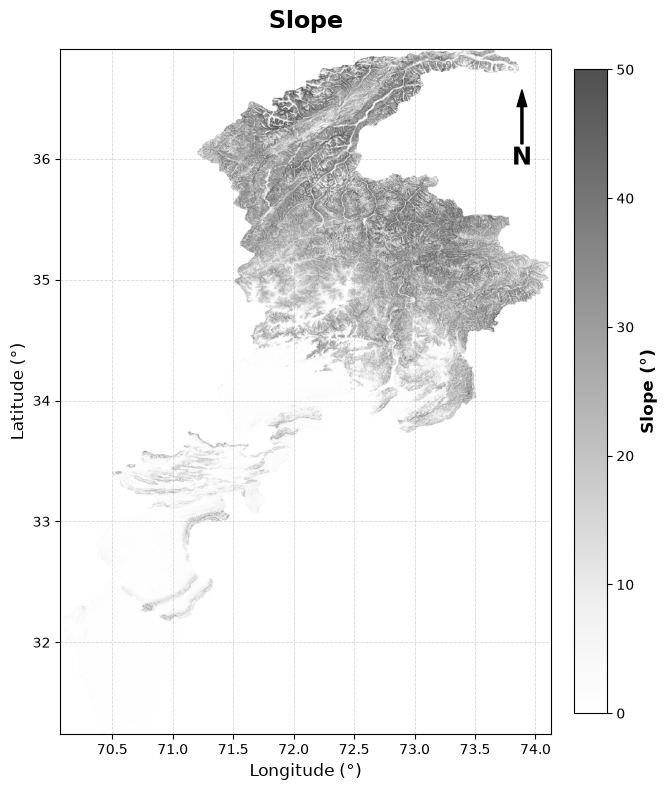

In [53]:
slope_vis = {
    "min": 0,
    "max": 50,
    "palette": ["ffffff", "f0f0f0", "d0d0d0", "b0b0b0", "909090", "707070", "505050"]
}
publication_map(
    slope,
    slope_vis,
    "Slope",
    "Slope (°)",
    0,
    50
)

Aspect map 

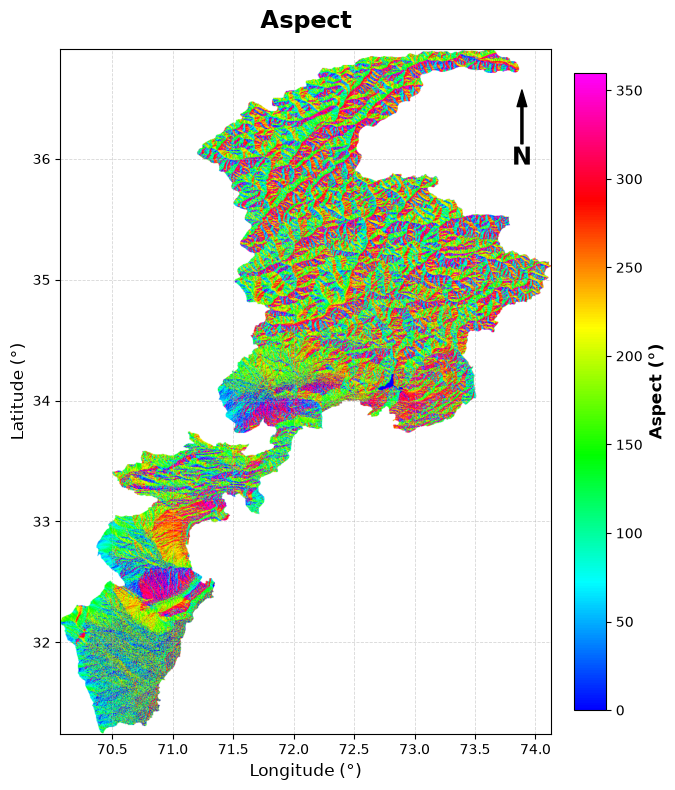

In [54]:
aspect_vis = {
    "min": 0,
    "max": 360,
    "palette": ["0000ff", "00ffff", "00ff00", "ffff00", "ff0000", "ff00ff"]
}
publication_map(
    aspect,
    aspect_vis,
    "Aspect",
    "Aspect (°)",
    0,
    360
)

flow accumulation map

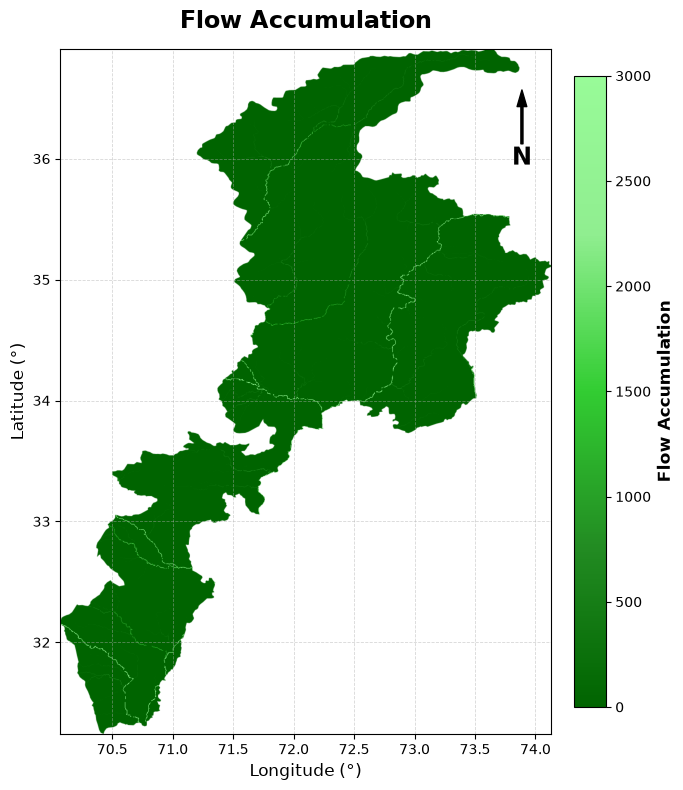

In [55]:
flow_acc_vis = {
    "min": 0,
    "max": 3000,
    "palette": [
        "006400",   # Dark green
        "228B22",   # Forest green
        "32CD32",   # Lime green
        "90EE90",   # Light green
        "98FB98"    # Pale green
    ]
}
publication_map(
    flow_acc,
    flow_acc_vis,
    "Flow Accumulation",
    "Flow Accumulation",
    0,
    3000
)